In [1]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

In [2]:
def trapezoid_shaper(v: NDArray, tau: float, T: float, k: int, l: int):
    """Shapes input signal pulse into a trapezoid for pulse height measurement.
    Algorithm by Jordanov et al. (1994)

    Args:
        v (np.ndarray): input signal
        tau (float): exponential decay constant
        T (float): sampling period
        k (int): delay parameter (rise)
        l (int): delay parameter (decay)

    Returns:
        np.ndarray: shaped signal
    """
    n_samples = len(v)
    M = 1 / (np.exp(T / tau) - 1)
    max_delay = k + l
    v_padded = np.concatenate(([0] * max_delay, v))

    dkl = np.zeros_like(v_padded)
    p = np.zeros_like(v_padded)
    r = np.zeros_like(v_padded)
    s = np.zeros_like(v_padded)

    for n in range(n_samples):
        dkl[n + max_delay] = v_padded[n + max_delay] - v_padded[n - k + max_delay] - v_padded[n - l + max_delay] + v_padded[n - k - l + max_delay]
        p[n + max_delay] = p[n - 1 + max_delay] + dkl[n + max_delay]
        r[n + max_delay] = p[n + max_delay] + M*dkl[n + max_delay]
        s[n + max_delay] = s[n - 1 + max_delay] + r[n + max_delay]

    return s[max_delay:]

def rccr2_filter(x: NDArray):
    """
    Apply the three-stage recursive RC-CR2 filter to the input signal x.

    Args:
        x (numpy.ndarray): Input signal.

    Returns:
        y3 (numpy.ndarray): Output signal after three stages of filtering.
    """
    x = np.asarray(x)
    N = len(x)

    # Initialize output arrays
    y1 = np.zeros(N+1)
    y2 = np.zeros(N+1)
    y3 = np.zeros(N+1)

    for n in range(1, N):
        y1[n] = 0.15 * x[n] + 0.84 * y1[n-1]
        y2[n] = 0.91 * y1[n] - 0.91 * y1[n-1] + 0.84 * y2[n-1]
        y3[n] = 0.91 * y2[n] - 0.91 * y2[n-1] + 0.84 * y3[n-1]

    return y3

def add_exp_pulse(s, pos, b, tau):
    """Add an exponentially decaying pulse to a base signal.

    Args:
        s (numpy.ndarray): base signal
        pos (int): starting index of the pulse
        b (float): height of the added pulse
        tau (float): exponential decay constant
        samples (int): number of samples in the 

    Returns:
        numpy.ndarray: base signal with exponential pulse starting from pos
    """
    samples = len(s)
    x = np.linspace(0, 1, samples)
    x = np.roll(x, pos)
    s1 = np.exp(- x / tau)
    s1[:pos] = 0
    return s + s1

def triggers(signal, threshold):
    """Given a threshold amplitude, find the triggers based on the RC-CR2 filtered signal.

    Args:
        signal (numpy.ndarray): RC-CR2 filtered signal
        threshold (float): threshold amplitude for arming the trigger

    Returns:
        list: trigger indices
    """
    trigger_indices = []
    i = 0
    while i < len(signal):
        over_threshold = np.nonzero((signal[i:] > threshold).astype(np.int64))[0]
        if over_threshold.shape[0] > 0:
            threshold_index = over_threshold[0] + i
        else:
            break
        trigger_index = np.nonzero((signal[threshold_index:] < 0))[0][0]
        trigger_indices.append(trigger_index + threshold_index)
        i = trigger_index + threshold_index

    return trigger_indices

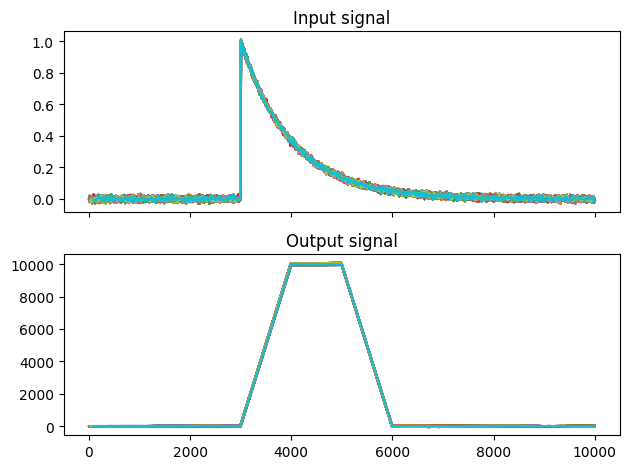

In [3]:
# Jittering MC
repeats = 1000
samples = 10000
T = 0.001
tau = 0.1
k = 100
l = 200
sigma = 0.01
b = 1
x = np.zeros(shape=(samples))
signal = add_exp_pulse(x, pos=3000, b=1, tau=tau) + np.random.normal(0, sigma, size=len(x))
maxima = []
fig, axs = plt.subplots(nrows=2, sharex=True)
for i in range(repeats):
    subsample_index = np.arange(start=np.random.randint(100), stop=10000, step=10)
    subsample = signal[subsample_index]
    s = trapezoid_shaper(subsample, tau, T, k, l)
    if i < 100:
        axs[0].plot(subsample_index, subsample)
        axs[0].set_title("Input signal")
        axs[1].plot(subsample_index, s)
        axs[1].set_title("Output signal")
    maxima.append(np.nanmax(s))

plt.tight_layout()

Text(0, 0.5, 'N')

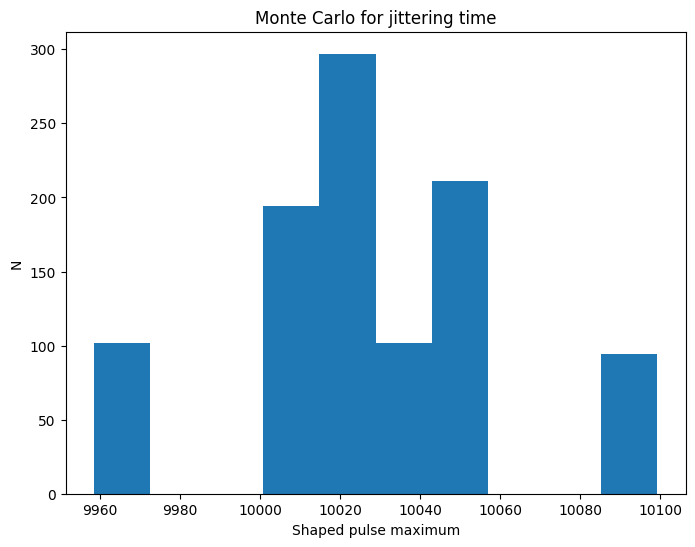

In [4]:
fig, axs = plt.subplots(figsize=(8,6))
plt.title("Monte Carlo for jittering time")
plt.hist(maxima)
plt.xlabel("Shaped pulse maximum")
plt.ylabel("N")

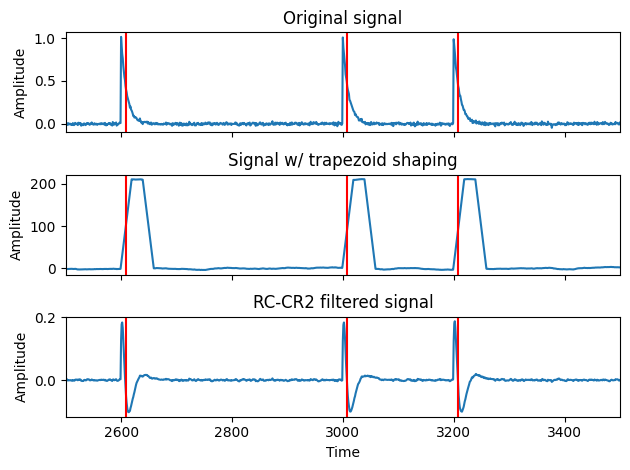

In [8]:
samples = 10000
T = 0.0001
tau = 0.001
k = 20
l = 40
sigma = 0.01
b = 1

rate = 1 / (20 * tau / T)t = 0
pulse_positions = []
    while t < samples:
        dt = np.random.exponential(scale=1/rate)
        t += int(dt)
        if t < samples:
        pulse_positions.append(t)
    for pos in pulse_positions:
        signal = add_exp_pulse(signal, pos=pos, b=b, tau=tau)
#signal = add_exp_pulse(signal, pos=2600, b=b, tau=tau)
#signal = add_exp_pulse(signal, pos=3000, b=b, tau=tau)
#signal = add_exp_pulse(signal, pos=3200, b=b, tau=tau)

filt_sig = rccr2_filter(signal)
trapez_sig = trapezoid_shaper(signal, tau, T, k, l)

threshold = 0.05
trigs = triggers(filt_sig, threshold)

fig, axs = plt.subplots(nrows=3, sharex=True)
axs[0].set_title("Original signal")
axs[0].set_ylabel("Amplitude")
axs[0].plot(signal)

axs[1].set_title("Signal w/ trapezoid shaping")
axs[1].set_ylabel("Amplitude")
axs[1].plot(trapez_sig)

axs[2].set_title("RC-CR2 filtered signal")
axs[2].set_ylabel("Amplitude")
axs[2].set_xlabel("Time")
axs[2].plot(filt_sig)

for ax in axs:
    for trig in trigs:
        ax.axvline(trig, color="red")

axs[2].set_xlim(2500, 3500)
plt.tight_layout()

In [ ]:
np.nonzero((signal > threshold).astype(np.int64))[0].shape[0] > 0

True